In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
print(pd.__version__)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

2.0.3
Libraries imported successfully!


In [16]:
df = pd.read_csv('../data/satilir_properties.csv')
print("Data loaded successfully!")
# - Dataset shape (hint: use df.shape)
print("Dataset shape:", df.shape)
# - Number of observations (hint: df.shape[0] gives rows)
print("Number of observations:", df.shape[0])
# - Number of features (hint: df.shape[1] gives columns)
print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (6183, 27)
Number of observations: 6183
Number of features: 27


In [17]:
df.drop(columns=['link'], inplace=True)
df.head()

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
0,200000,3.0,65.0,NaN,5.0,No,"Bakı, Nərimanov, metro 28 May",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No
1,800000,4.0,197.0,NaN,9.0,Yes,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
2,210000,2.0,54.0,NaN,12.0,No,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,149000,4.0,100.0,NaN,2.0,Yes,"Bakı, Binəqədi, Biləcəri qəs.",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No
4,45000,1.0,44.0,NaN,1.0,Yes,Xırdalan,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6183 entries, 0 to 6182
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     6183 non-null   int64  
 1   rooms                     6181 non-null   float64
 2   area_m2                   5923 non-null   float64
 3   land_area_sot             1196 non-null   float64
 4   floor                     6181 non-null   float64
 5   has_document              6183 non-null   object 
 6   address                   6183 non-null   object 
 7   avtodayanacaq             6183 non-null   object 
 8   balkon                    6183 non-null   object 
 9   duzelme                   6183 non-null   object 
 10  esyali                    6183 non-null   object 
 11  hovuz                     6183 non-null   object 
 12  internet                  6183 non-null   object 
 13  isiq                      6183 non-null   object 
 14  kabel_tv

In [19]:
df.head()

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
0,200000,3.0,65.0,NaN,5.0,No,"Bakı, Nərimanov, metro 28 May",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No
1,800000,4.0,197.0,NaN,9.0,Yes,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
2,210000,2.0,54.0,NaN,12.0,No,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,149000,4.0,100.0,NaN,2.0,Yes,"Bakı, Binəqədi, Biləcəri qəs.",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No
4,45000,1.0,44.0,NaN,1.0,Yes,Xırdalan,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [20]:
print(df.duplicated().sum())

216


In [21]:
dup_rows = df[df.duplicated(keep=False)]  # all duplicates grouped together
dup_rows.sort_index()  # optional: keep original order

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
77,115000,3.0,75.0,NaN,2.0,Yes,"Bakı, Abşeron, Masazır",Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,No
112,10000,2.0,50.0,NaN,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No
113,10000,2.0,50.0,NaN,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No
114,10000,2.0,50.0,NaN,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No
180,398000,4.0,NaN,6.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6044,65000,2.0,38.0,NaN,5.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
6054,130000,2.0,55.0,NaN,2.0,No,"Bakı, Xətai, Əhmədli, metro Həzi Aslanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
6078,368000,3.0,100.0,NaN,13.0,Yes,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
6113,65000,2.0,65.0,NaN,12.0,Yes,"Bakı, Binəqədi, 7-ci mikrorayon, metro Dərnəgül",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [22]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)

In [23]:
print(df.duplicated().sum())

0


In [24]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numerical columns:", len(num_cols))
print("Numerical columns:", num_cols)

Number of numerical columns: 5
Numerical columns: ['price', 'rooms', 'area_m2', 'land_area_sot', 'floor']


In [25]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Number of categorical columns:", len(cat_cols))
print("Categorical columns:", cat_cols)

Number of categorical columns: 21
Categorical columns: ['has_document', 'address', 'avtodayanacaq', 'balkon', 'duzelme', 'esyali', 'hovuz', 'internet', 'isiq', 'kabel_tv', 'kombi', 'kondisioner', 'lift', 'merkezi_qizdirici_sistem', 'metbex_mebeli', 'pvc_pencere', 'qaz', 'su', 'telefon', 'temirli', 'temirsiz']


In [26]:
print("Unique values for each column: \n", df[cat_cols].nunique().sort_values(ascending=False))

Unique values for each column: 
 address                     257
has_document                  2
kondisioner                   2
temirli                       2
telefon                       2
su                            2
qaz                           2
pvc_pencere                   2
metbex_mebeli                 2
merkezi_qizdirici_sistem      2
lift                          2
kombi                         2
kabel_tv                      2
isiq                          2
internet                      2
hovuz                         2
esyali                        2
duzelme                       2
balkon                        2
avtodayanacaq                 2
temirsiz                      2
dtype: int64


In [27]:
mis_values = df.isnull().sum()
mis_percent = (mis_values / len(df)) * 100

df_mis = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": mis_values,
    "Percentage": mis_percent
})

df_mis = df_mis[df_mis["Missing Values"] > 0].sort_values(by="Percentage", ascending=False).reset_index(drop=True)
# TODO: Print summary
# - Number of features with missing values
# - The missing values summary DataFrame
print(f"Number of features with missing values: {df_mis.shape[0]}")
df_mis

Number of features with missing values: 4


,Column,Missing Values,Percentage
0,land_area_sot,4789,80.258086
1,area_m2,252,4.223228
2,rooms,2,0.033518
3,floor,2,0.033518


In [28]:
df_clean = df.copy()
df_clean["land_area_sot"] = df_clean["land_area_sot"].fillna(0)

In [29]:
df_clean.loc[df_clean["rooms"].isnull()]

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
1004,500000,NaN,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No
1010,35000,NaN,16.0,0.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,Yes,No


In [30]:
df_clean.query("area_m2 <= 30")

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
37,54500,2.0,29.0,0.0,3.0,No,Xırdalan,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No
56,54000,1.0,30.0,0.0,5.0,No,Xırdalan,Yes,No,Yes,No,No,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,Yes,Yes,Yes,No
93,128000,1.0,30.0,0.0,4.0,Yes,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
156,39000,1.0,27.0,0.0,6.0,No,Xırdalan,No,Yes,No,No,No,No,Yes,No,No,No,Yes,No,No,Yes,Yes,Yes,No,No,Yes
193,38500,2.0,25.0,0.0,8.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
245,59000,1.0,29.0,0.0,2.0,No,Xırdalan,No,Yes,No,Yes,No,No,Yes,No,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No
286,21000,1.0,8.0,0.0,1.0,Yes,"Bakı, Yasamal, metro İçərişəhər",No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,No,Yes,No,Yes,No
592,65000,1.0,30.0,0.1,1.0,Yes,"Bakı, Yasamal",No,No,No,No,No,No,Yes,No,No,No,No,No,No,Yes,No,Yes,Yes,No,No
598,39000,1.0,15.0,1.0,3.0,No,"Bakı, Yasamal, metro Nizami",No,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,No,Yes,No,No,No
710,120000,1.0,30.0,0.0,4.0,Yes,"Bakı, Yasamal, metro İnşaatçılar",No,No,No,Yes,No,Yes,Yes,No,No,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No


In [31]:
df_clean.loc[(df_clean["price"] == 35000) & (df_clean["rooms"].isnull()), "rooms"] = 1

In [32]:
df_clean.query("price >= 500000 and land_area_sot >= 25")

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
285,560000,8.0,NaN,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Yes,No
845,1300000,12.0,800.0,30.0,2.0,Yes,"Bakı, Xəzər",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No
1004,500000,NaN,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No
1529,1300000,5.0,500.0,51.0,3.0,Yes,"Bakı, Sabunçu, Bilgəh qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1656,560000,8.0,510.0,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No
3234,900000,9.0,NaN,25.0,3.0,Yes,"Bakı, Sabunçu",No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No


In [33]:
df_clean.loc[(df_clean["price"] == 500000) & (df_clean["rooms"].isnull()), "rooms"] = 7

In [34]:
df_clean.loc[df_clean["floor"].isnull()]

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
1004,500000,7.0,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No
1010,35000,1.0,16.0,0.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,Yes,No


In [35]:
df_clean.query("land_area_sot > 0")["floor"].unique()

array([ 1.,  3.,  2.,  4., nan])

In [36]:
df_clean.query("price >= 500000 and land_area_sot >= 25")

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
285,560000,8.0,NaN,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Yes,No
845,1300000,12.0,800.0,30.0,2.0,Yes,"Bakı, Xəzər",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No
1004,500000,7.0,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No
1529,1300000,5.0,500.0,51.0,3.0,Yes,"Bakı, Sabunçu, Bilgəh qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1656,560000,8.0,510.0,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No
3234,900000,9.0,NaN,25.0,3.0,Yes,"Bakı, Sabunçu",No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No


In [37]:
df_clean.loc[(df_clean["price"] == 500000) & (df_clean["floor"].isnull()), "floor"] = 2

In [38]:
df_clean.query("price == 35000 and land_area_sot == 0")

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,temirsiz
231,35000,2.0,35.00,0.0,1.0,Yes,"Bakı, Sabunçu, Bakıxanov qəs., metro Neftçilər",No,No,No,Yes,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,No,Yes
785,35000,3.0,130.00,0.0,2.0,Yes,Xırdalan,Yes,No,No,Yes,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No
829,35000,2.0,81.00,0.0,1.0,Yes,"Bakı, Abşeron, Saray",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
880,35000,1.0,81.00,0.0,1.0,Yes,"Sumqayıt, St.Sumqayıt",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1010,35000,1.0,16.00,0.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,Yes,No
1161,35000,2.0,63.00,0.0,3.0,Yes,"Bakı, Abşeron, Saray",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1238,35000,2.0,73.00,0.0,7.0,Yes,"Bakı, Yasamal, Yeni Yasamal qəs., metro İnşaat...",Yes,Yes,No,No,No,No,Yes,No,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No
1286,35000,2.0,72.00,0.0,5.0,No,"Bakı, Yasamal, Yeni Yasamal qəs., metro İnşaat...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
2490,35000,2.0,77.00,0.0,14.0,Yes,"Sumqayıt, Sumqayıt Bulvarı",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
2961,35000,3.0,88.00,0.0,7.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No


In [39]:
df_clean.loc[(df_clean["price"] == 35000) & (df_clean["floor"].isnull()), "floor"] = 2

In [41]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols_for_impute = [c for c in ["area_m2", "price", "land_area_sot", "floor", "rooms"] if c in df_clean.columns]
if "area_m2" not in cols_for_impute:
    raise KeyError("'area_m2' column not found in df_clean")

imputer = IterativeImputer(random_state=42, max_iter=20, sample_posterior=False)
imputed_array = imputer.fit_transform(df_clean[cols_for_impute])
area_idx = cols_for_impute.index("area_m2")
df_clean["area_m2"] = imputed_array[:, area_idx]

df_clean["area_m2"].isnull().sum()

0

In [42]:
df_clean.isnull().sum().sum()

0

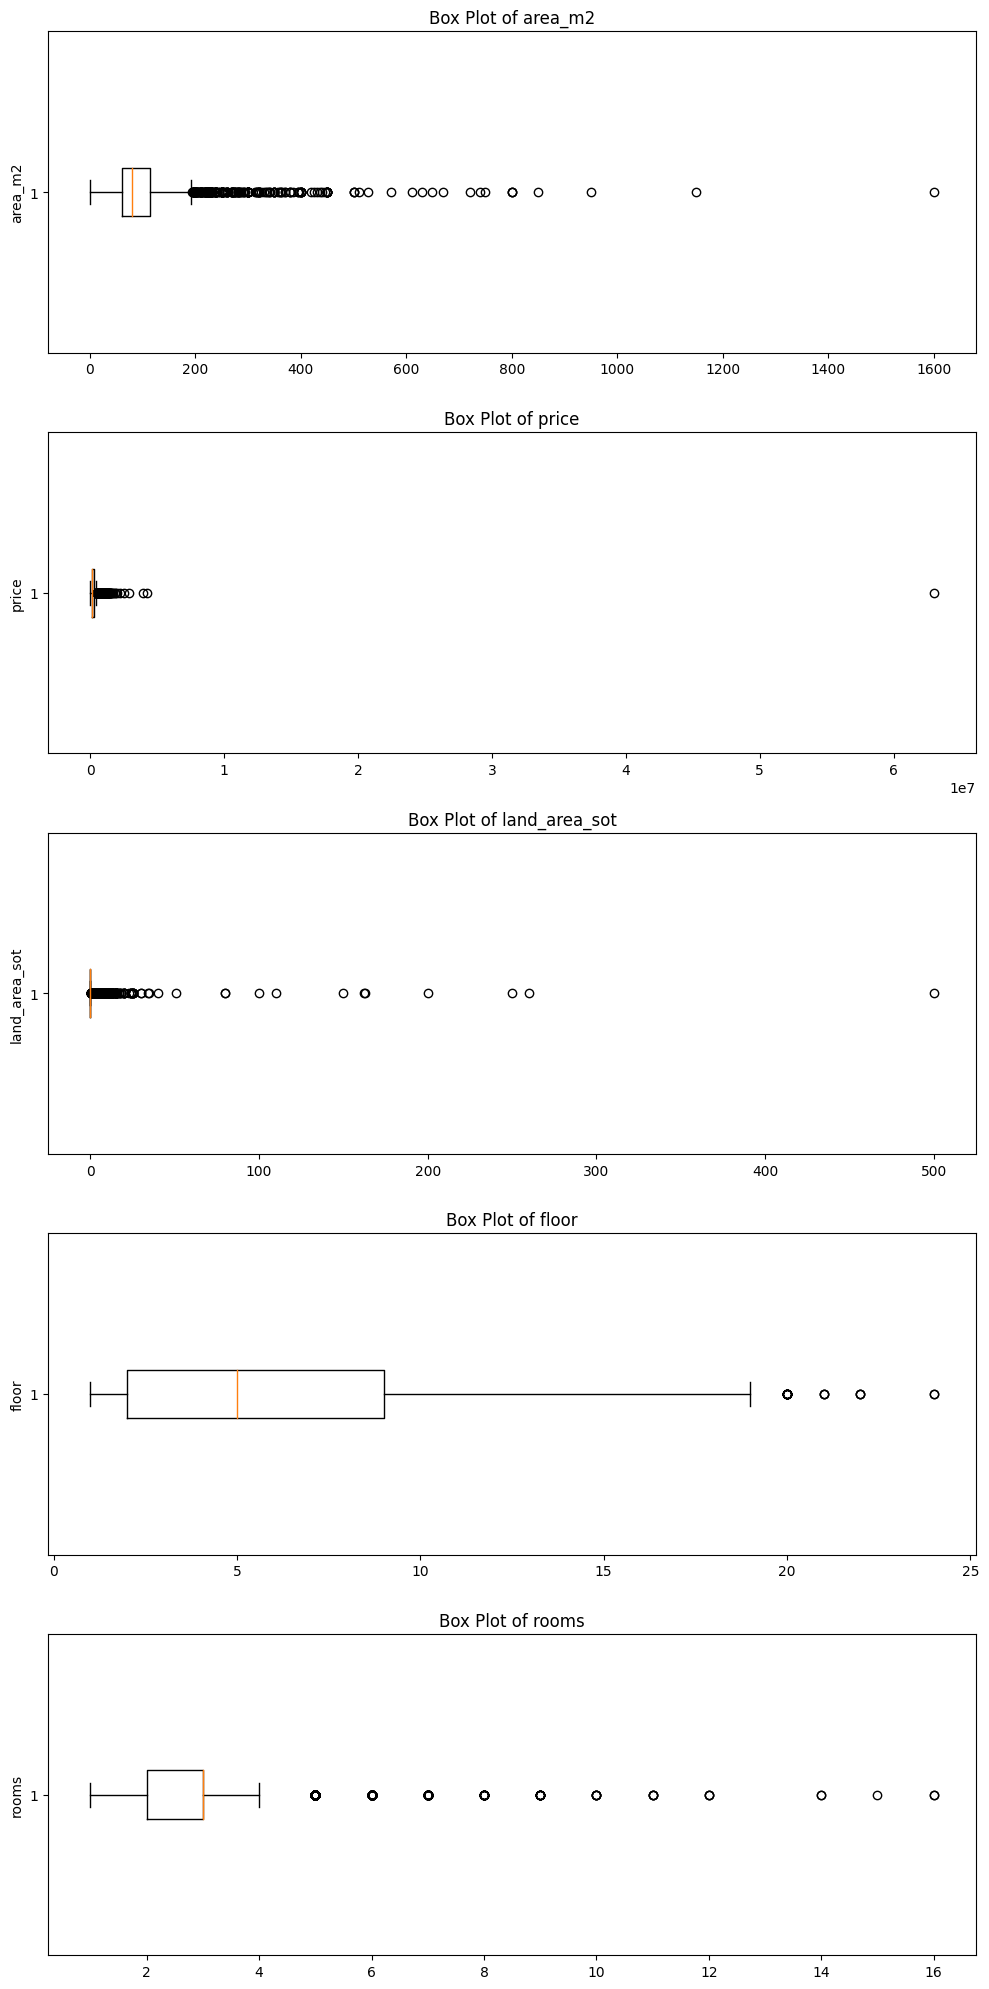

In [43]:
key_numeric_features = ["area_m2", "price", "land_area_sot", "floor", "rooms"]
key_numeric_features = [col for col in key_numeric_features if col in df_clean.columns]

fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(10, 4*len(key_numeric_features)))

if len(key_numeric_features) == 1:
    axes = [axes]
for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

In [44]:
def IQR_finding_outliers(df,column):
    Q1 = np.percentile(df[column].dropna(),25)
    Q3 = np.percentile(df[column].dropna(),75)
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound ,upper_bound

for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers found: {outliers.shape[0]}\n")
    

Column: area_m2
Lower Bound: -20.25, Upper Bound: 193.75
Number of outliers found: 325

Column: price
Lower Bound: -133750.0, Upper Bound: 456250.0
Number of outliers found: 381

Column: land_area_sot
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers found: 1178

Column: floor
Lower Bound: -8.5, Upper Bound: 19.5
Number of outliers found: 23

Column: rooms
Lower Bound: 0.5, Upper Bound: 4.5
Number of outliers found: 472



In [45]:
for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


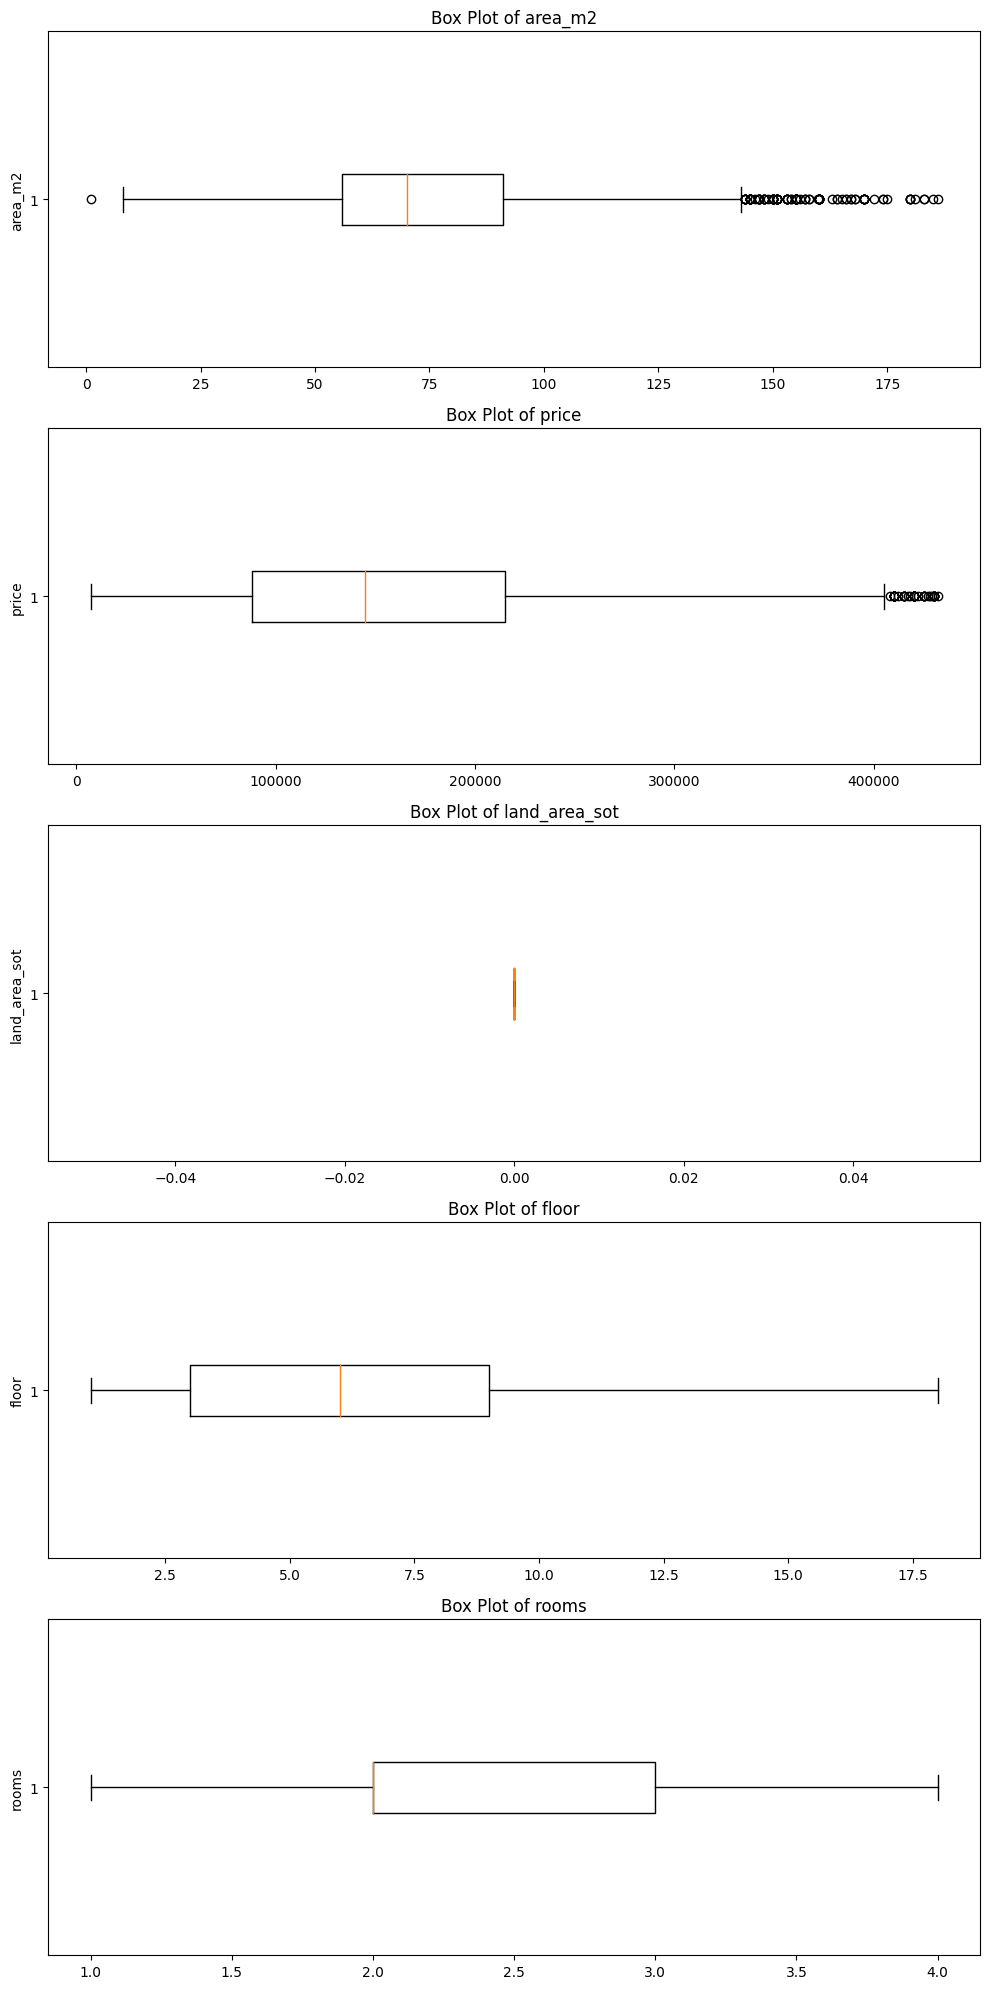

In [46]:
fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(10, 4*len(key_numeric_features)))
if len(key_numeric_features) == 1:
    axes = [axes]
for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

In [47]:
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
# - Number of rows removed
print(f"Number of rows removed: {df.shape[0] - df_clean.shape[0]}")
# - Number of columns removed
print(f"Number of columns removed: {df.shape[1] - df_clean.shape[1]}")
# - Remaining missing values count
print(f"Remaining missing values count: {df_clean.isnull().sum().sum()}")
# - Data types value counts
print("Data types value counts:")
print(df_clean.dtypes.value_counts())

Original dataset shape: (5967, 26)
Cleaned dataset shape: (4417, 26)
Number of rows removed: 1550
Number of columns removed: 0
Remaining missing values count: 0
Data types value counts:
object     21
float64     4
int64       1
Name: count, dtype: int64


In [48]:
# TODO: Save the cleaned dataset to CSV
df_clean.to_csv('../data/satilir_properties_cleaned.csv', index=False)
# - Print confirmation message
print("Cleaned dataset saved to 'data/satilir_properties_cleaned.csv'")

Cleaned dataset saved to 'data/satilir_properties_cleaned.csv'
